# Dimer detection

In [1]:
import tfmindi as tm

import numpy as np
from tqdm import tqdm

%matplotlib inline

DATA_DIR = "../../../../data/tfmindi/"  # change to your project's data directory

In [2]:
# fetch collection and annotations
motif_collection_dir = tm.fetch_motif_collection()
motif_annotations_file = tm.fetch_motif_annotations()

# to speed up all analyses, we can choose to only load a sampled subset of motifs. We have selected some and stored those names in a .txt file.
motif_samples_path = DATA_DIR + "sampled_motifs.txt"
with open(motif_samples_path) as f:
    motif_names = [line.strip() for line in f.readlines()]

# load them as dictionary of PPM matrices
motif_collection = tm.load_motif_collection(motif_collection_dir, motif_names=motif_names)
motif_annotations = tm.load_motif_annotations(motif_annotations_file)

# load motif to dna-binding domain (DBD) mapping
motif_to_db = tm.load_motif_to_dbd(motif_annotations)

In [3]:
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

In [4]:
patterns = tm.tl.create_patterns(adata, method="kmer")

Creating patterns for 63 clusters...


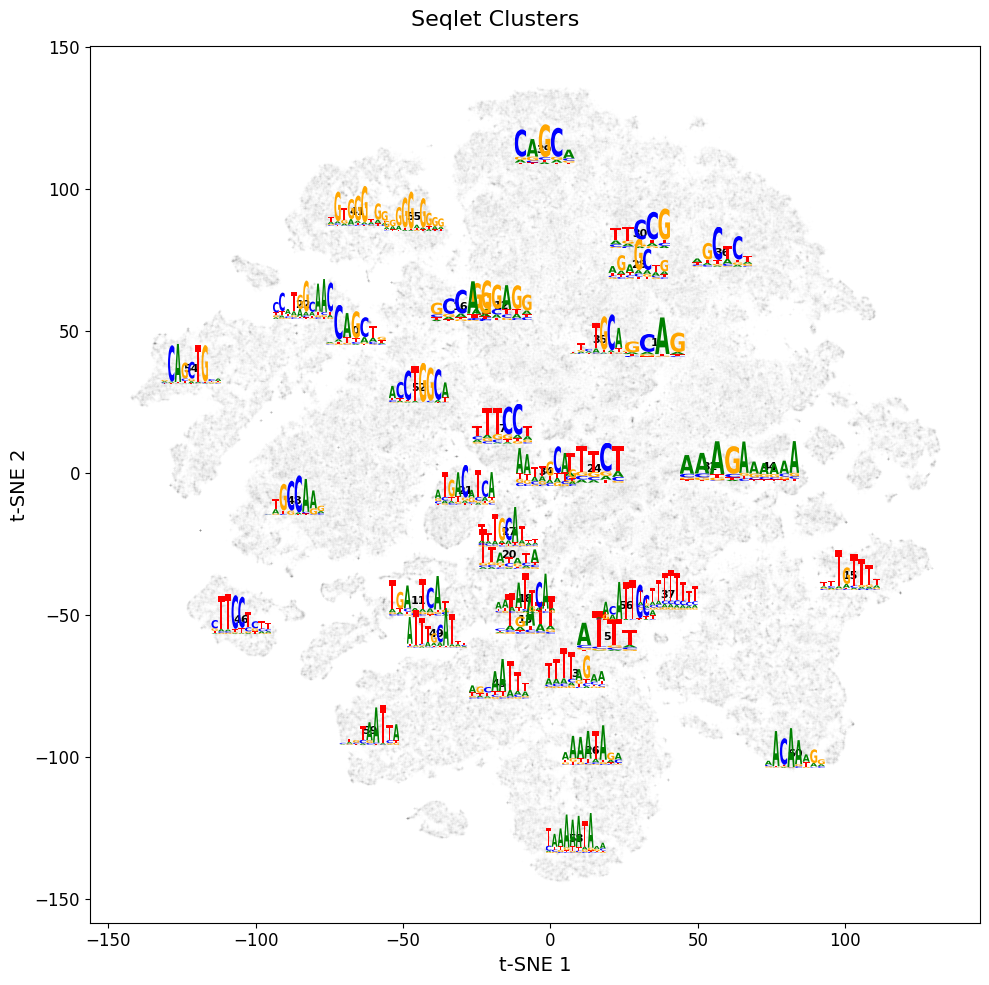

In [9]:
tm.pl.tsne_logos(
    adata,
    patterns,
    gray_background=True,  # ignore cmap and make all points gray for better pattern visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=10,
    height=10,
    s=0.3,
    alpha=0.01,  # background alpha
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_seqlets=10,  # ignore patterns with less than this many seqlets in the cluster
)

 32%|███▏      | 20/63 [00:00<00:00, 61.08it/s]/data/tmp/434914/ipykernel_2141406/594622668.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
100%|██████████| 63/63 [00:01<00:00, 53.98it/s]


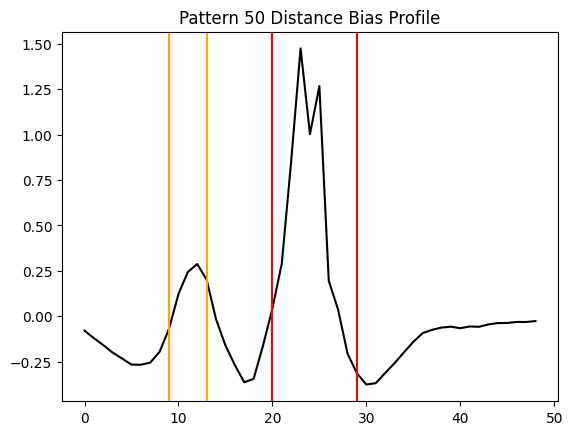

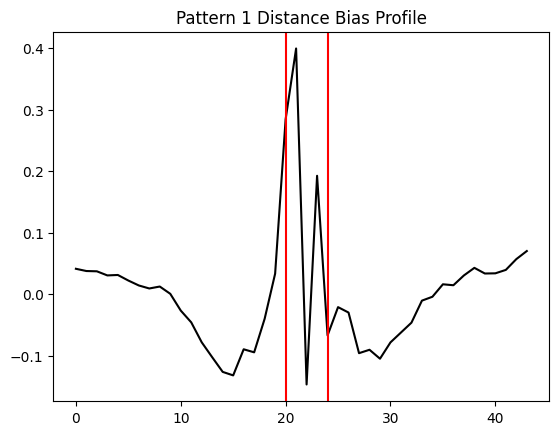

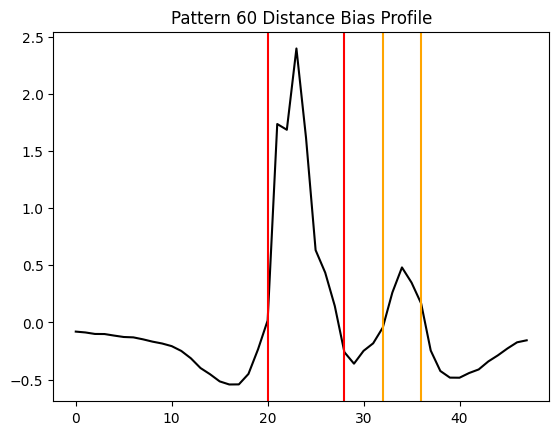

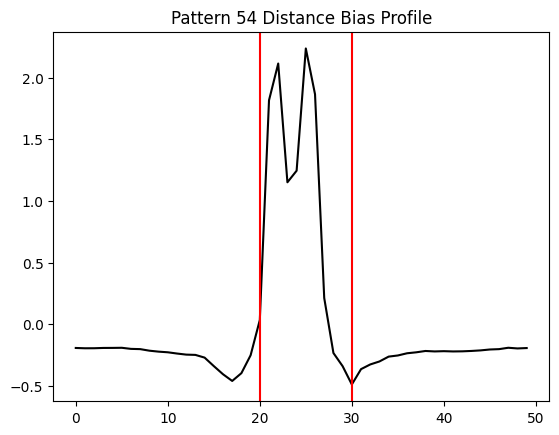

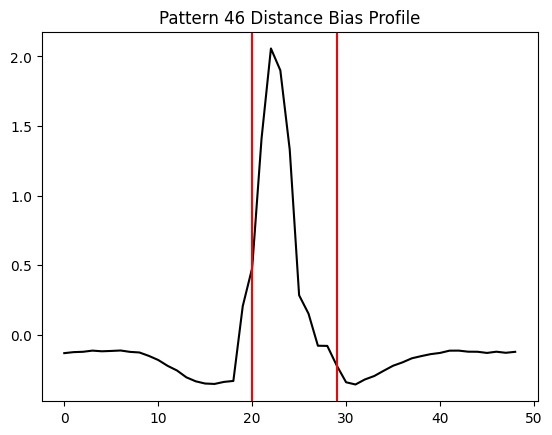

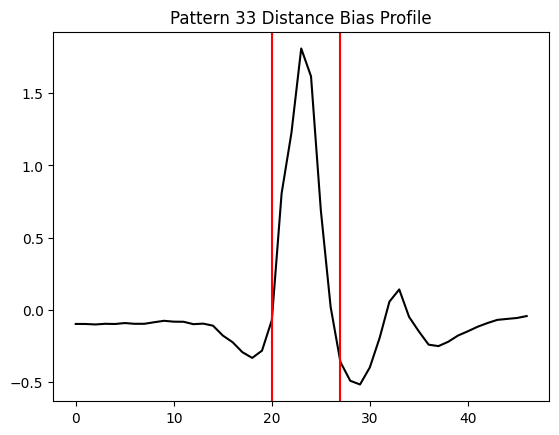

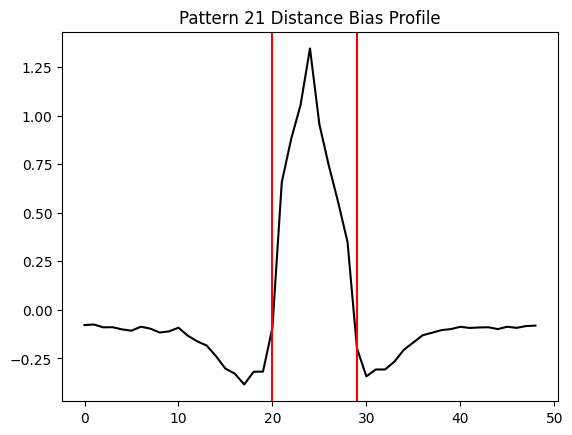

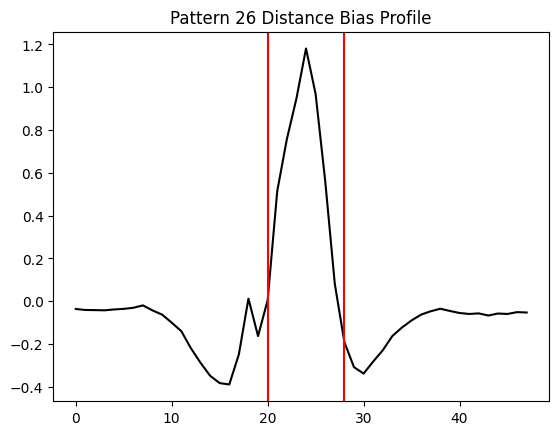

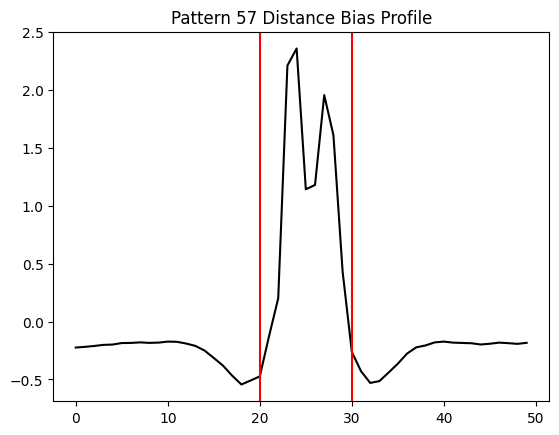

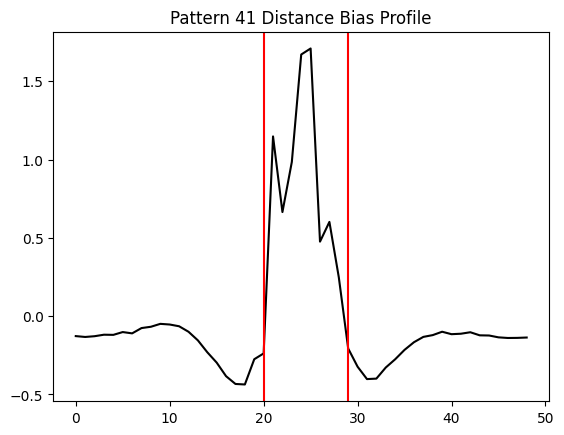

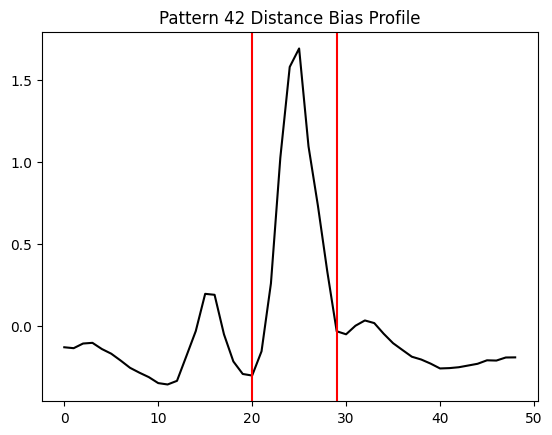

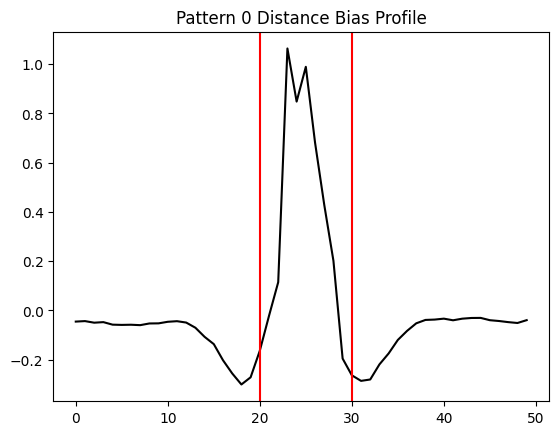

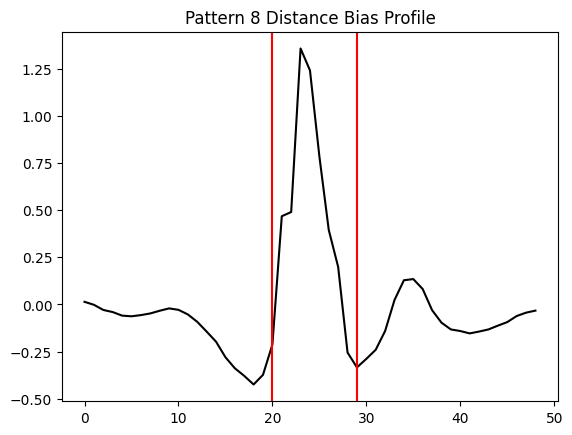

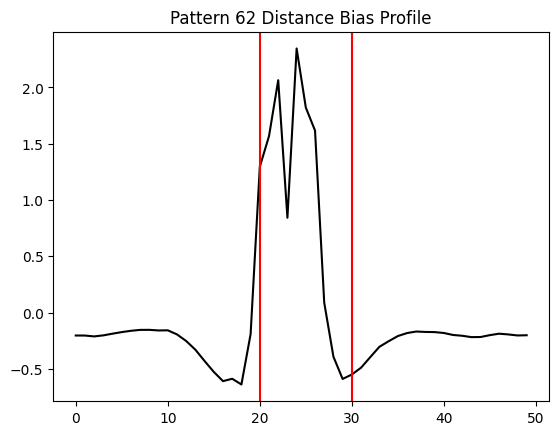

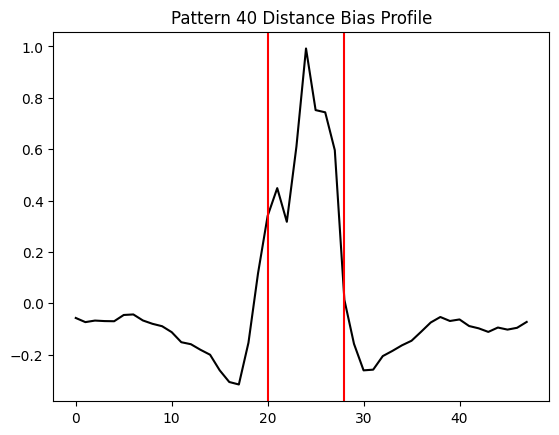

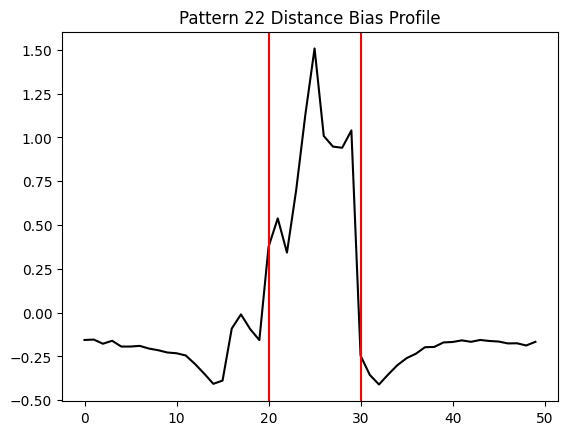

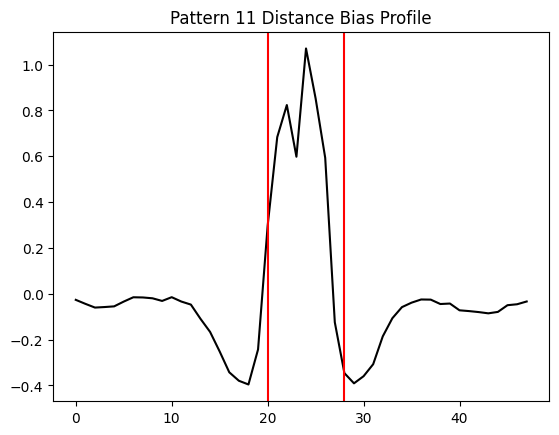

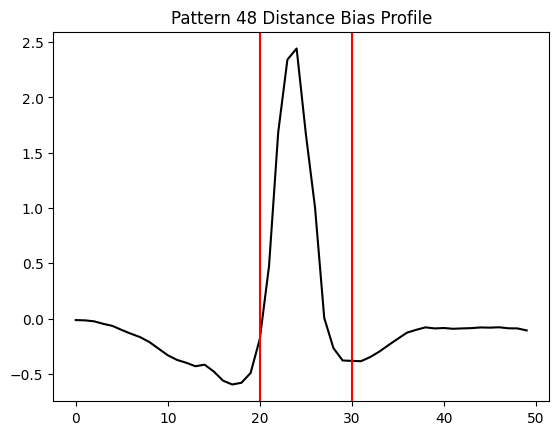

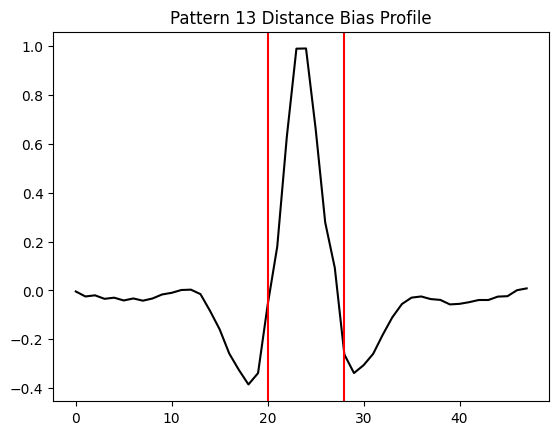

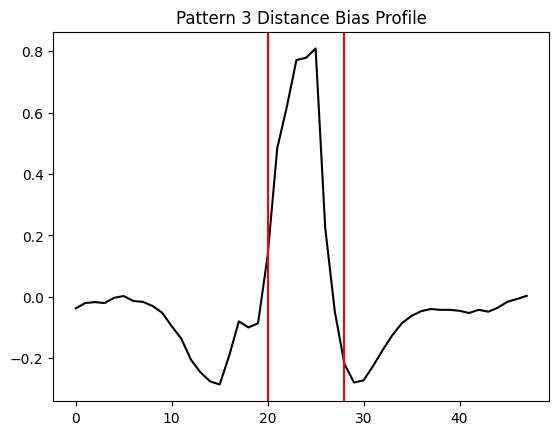

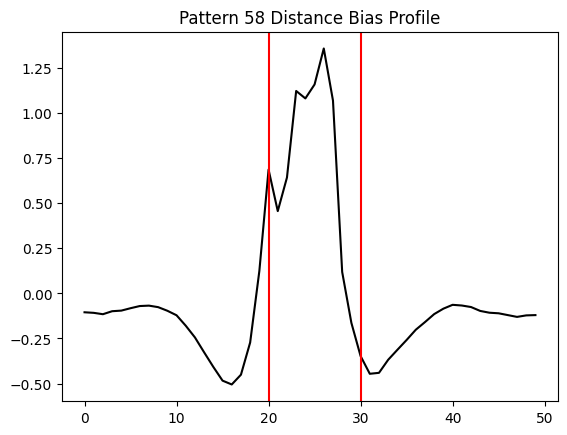

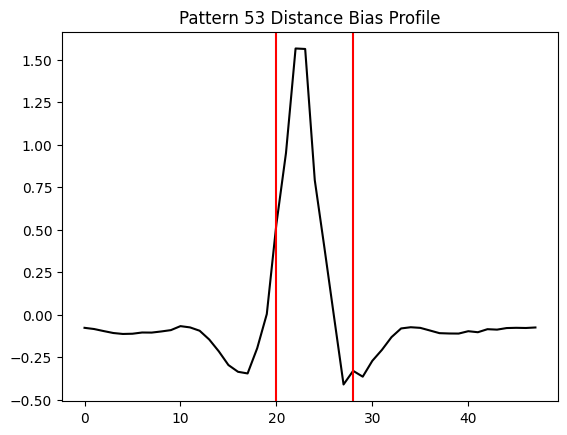

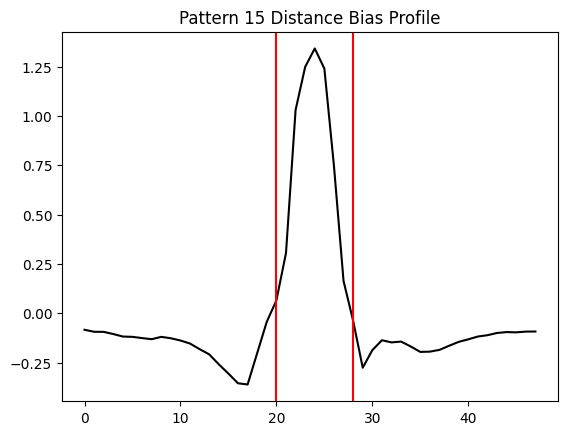

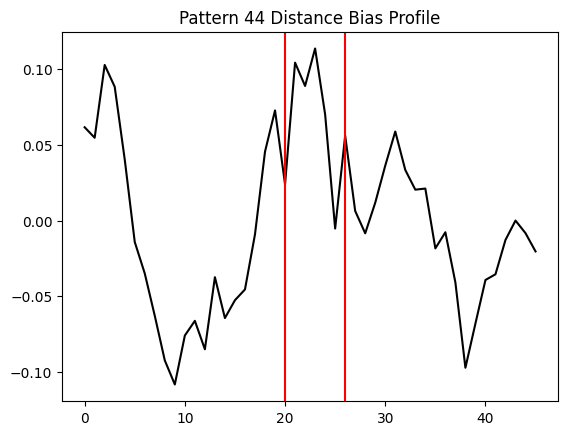

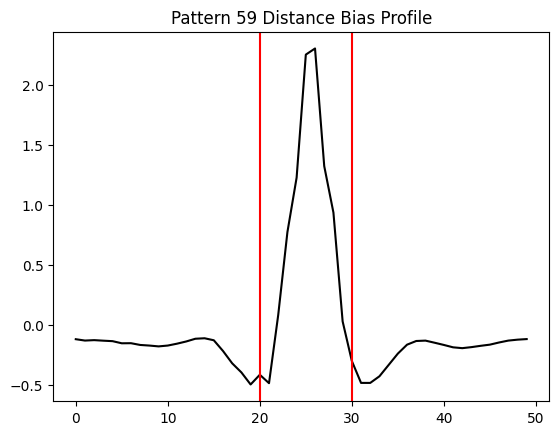

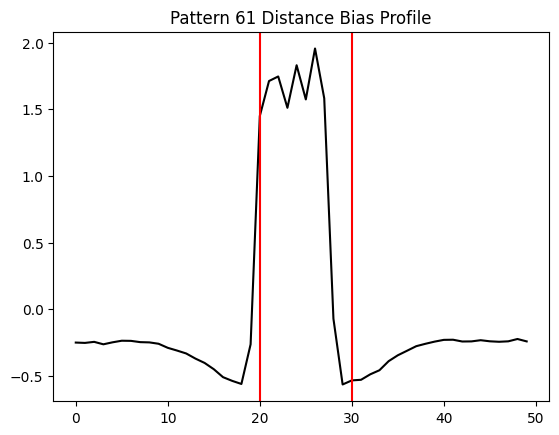

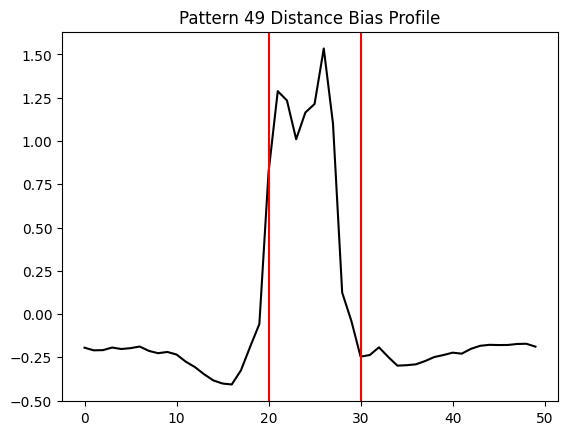

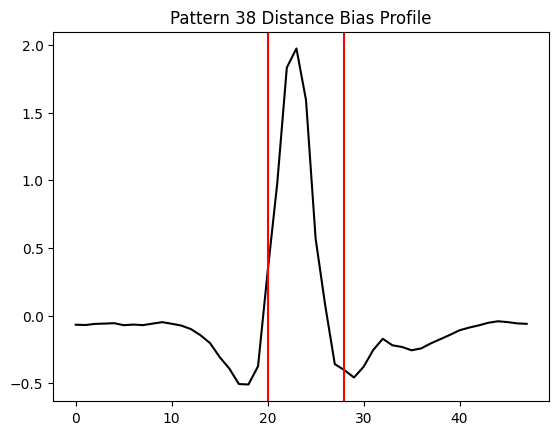

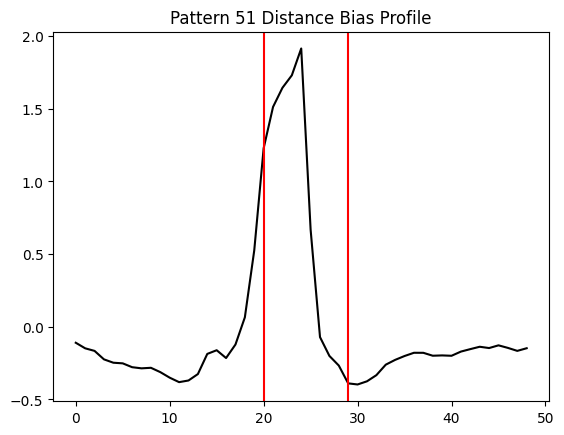

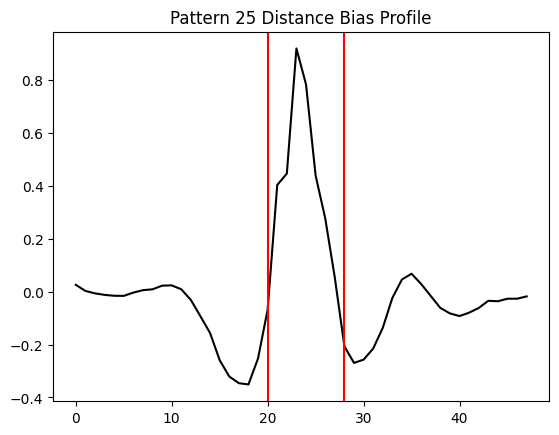

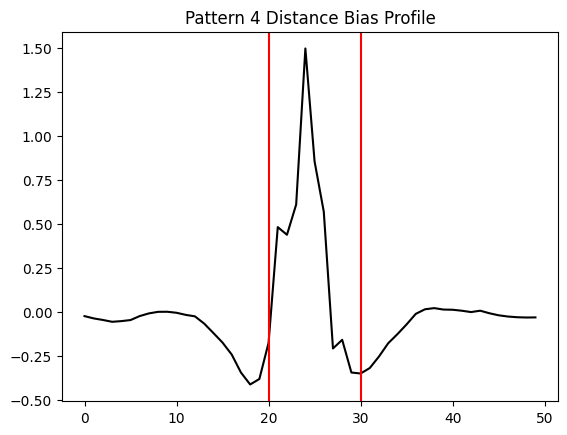

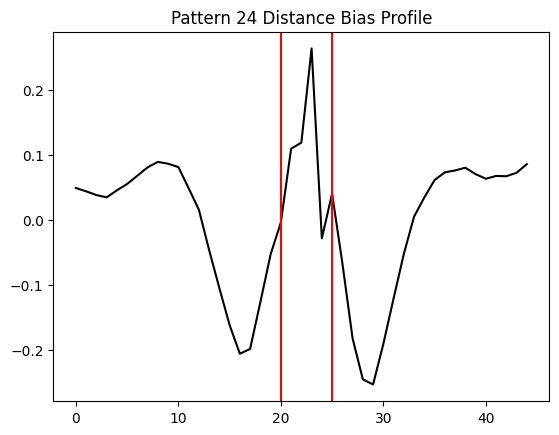

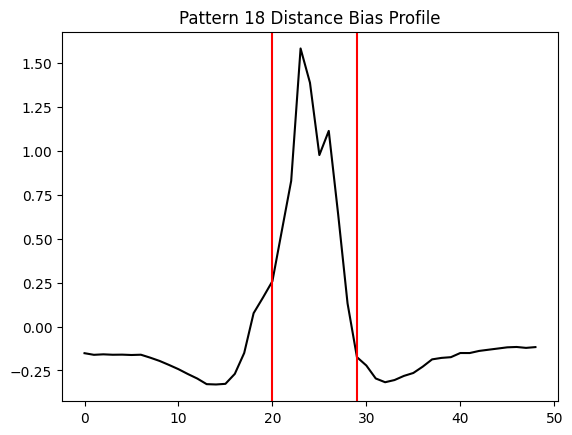

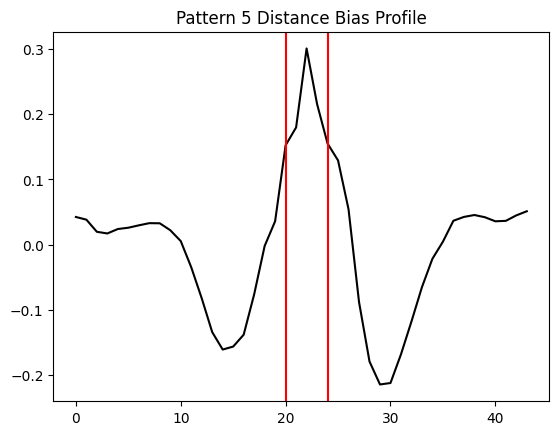

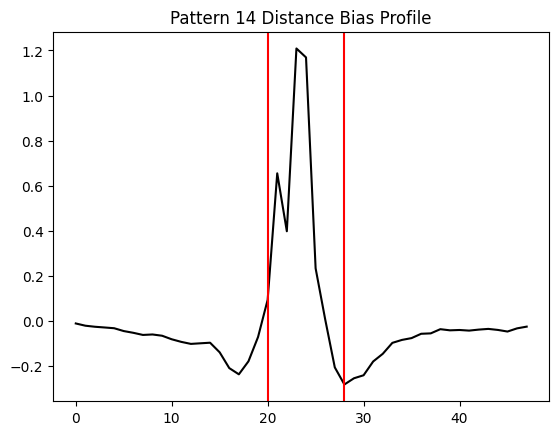

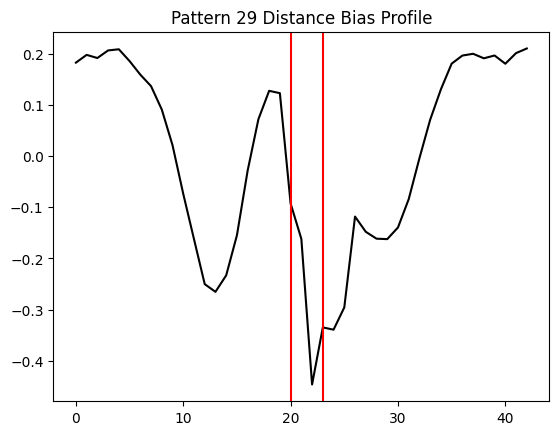

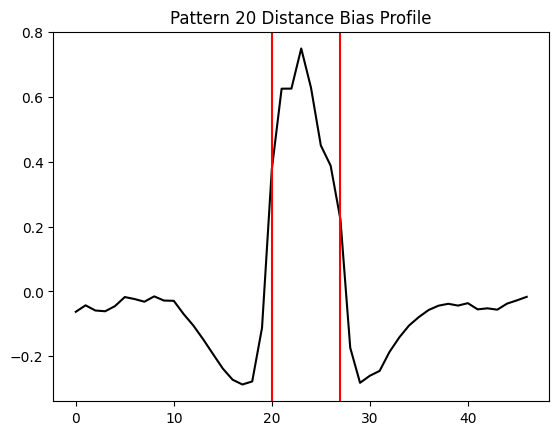

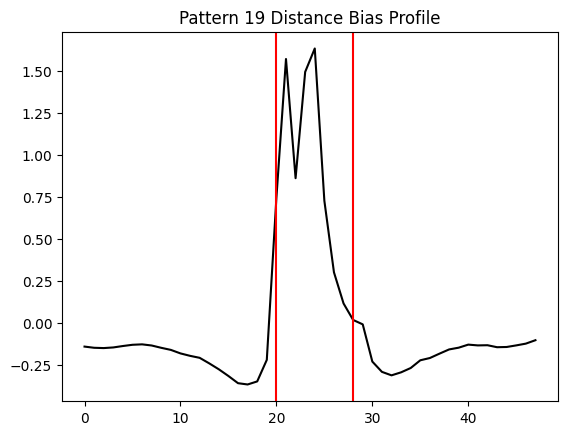

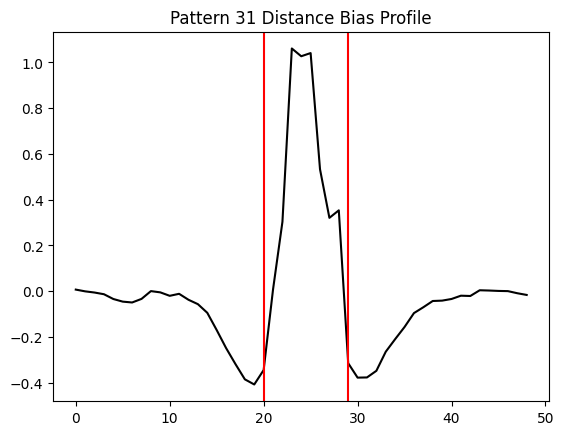

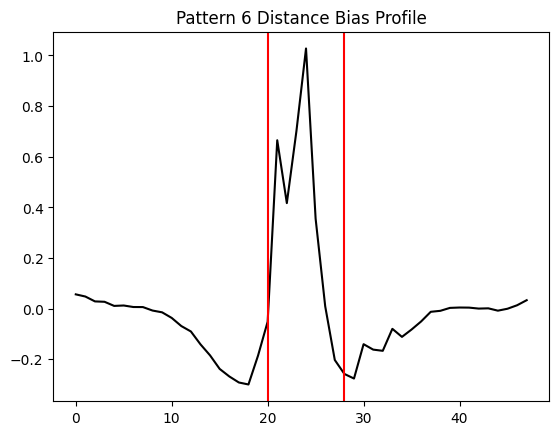

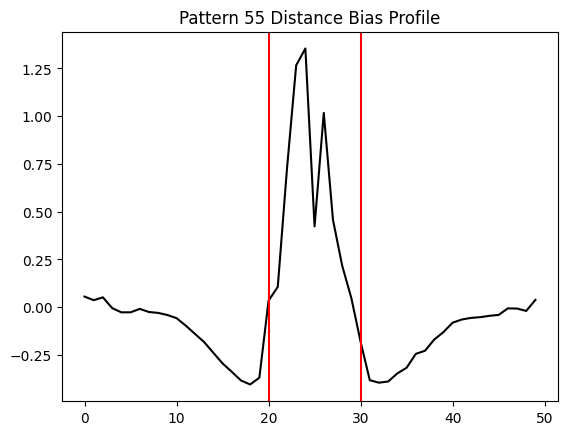

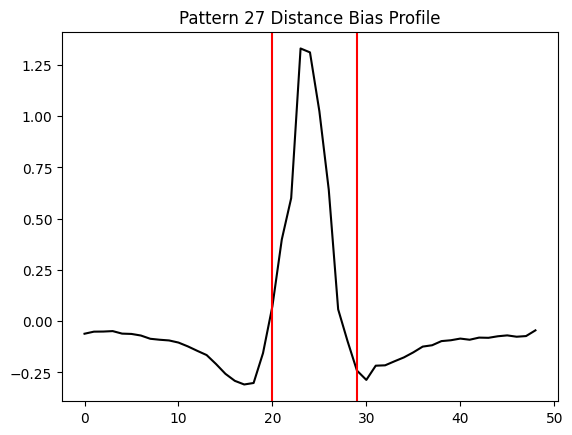

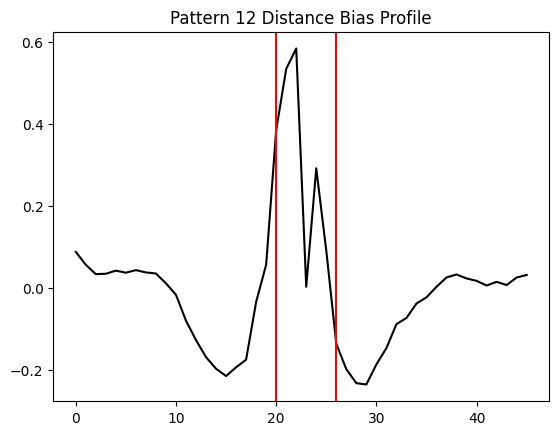

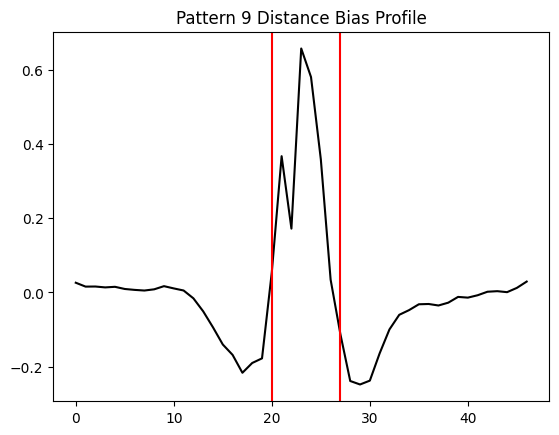

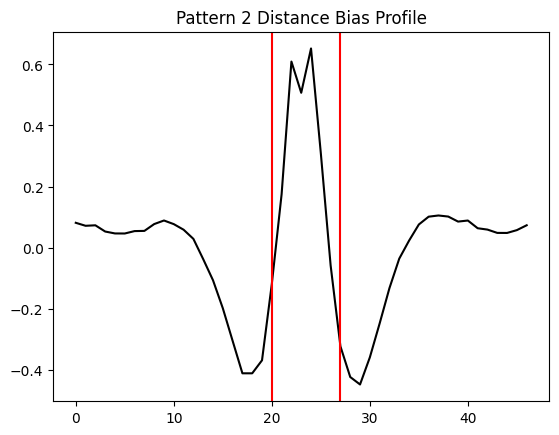

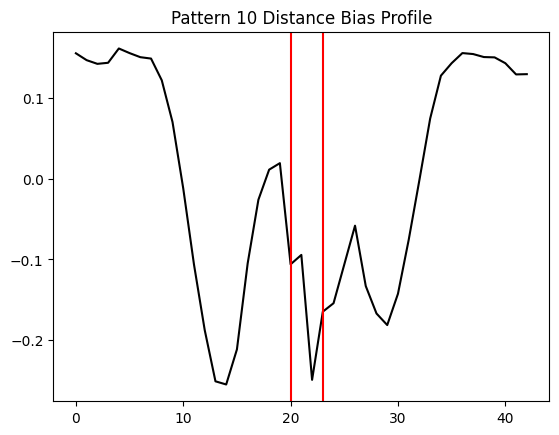

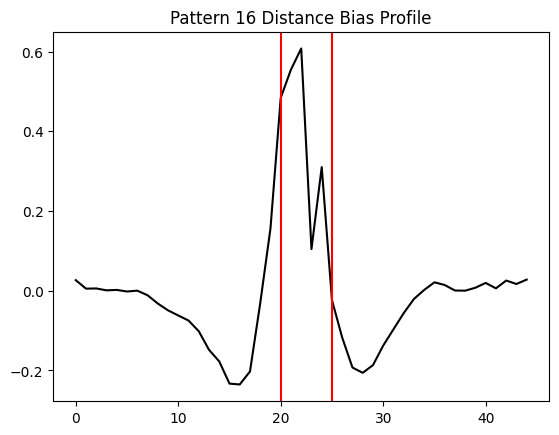

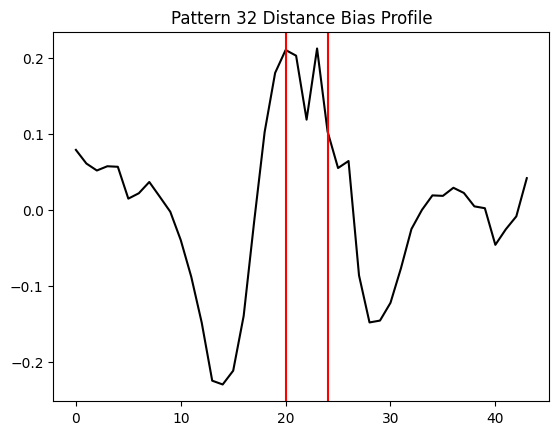

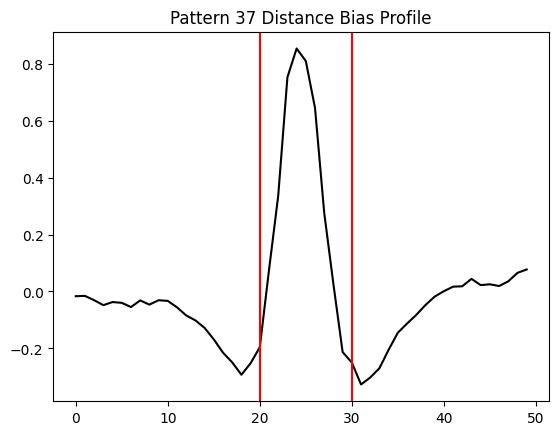

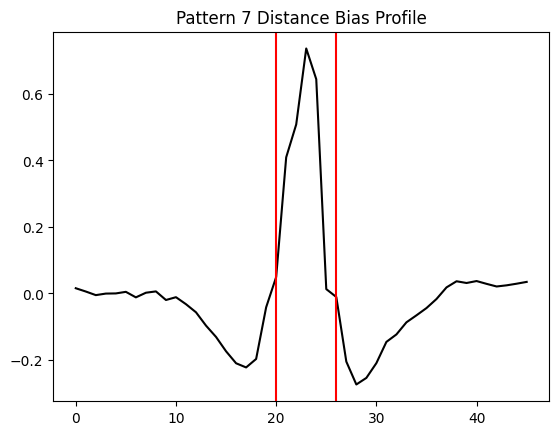

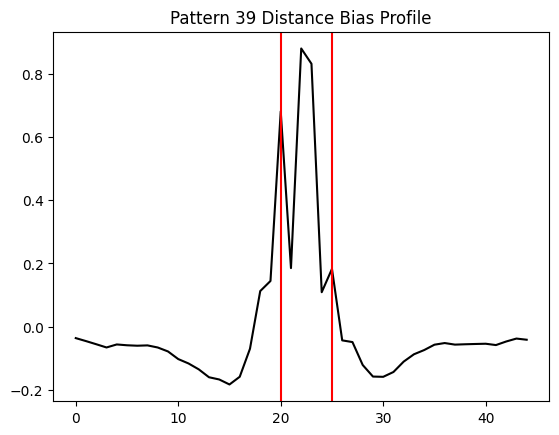

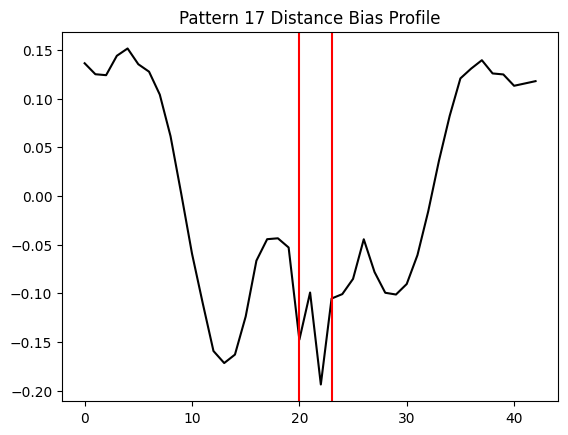

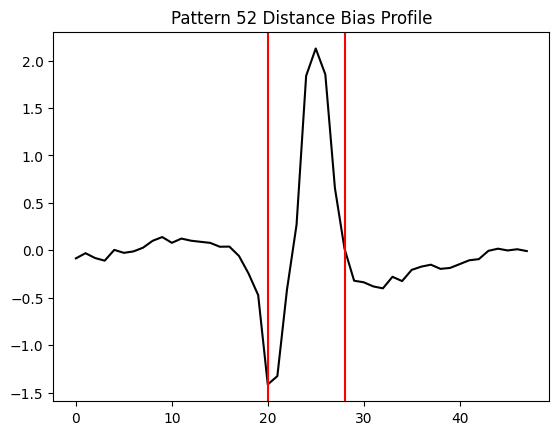

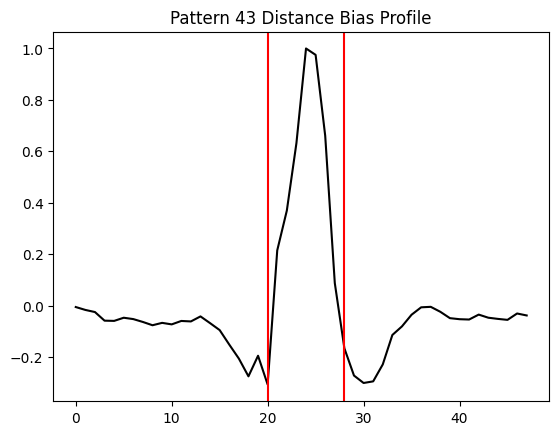

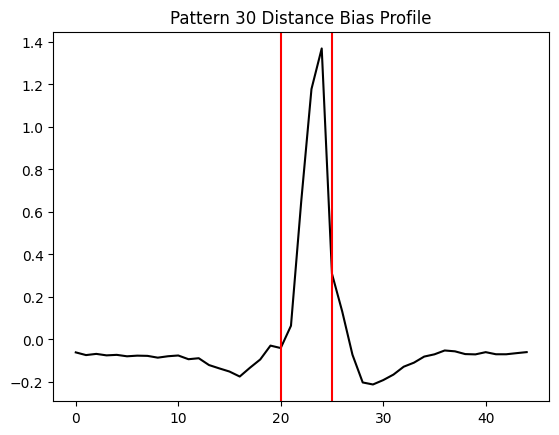

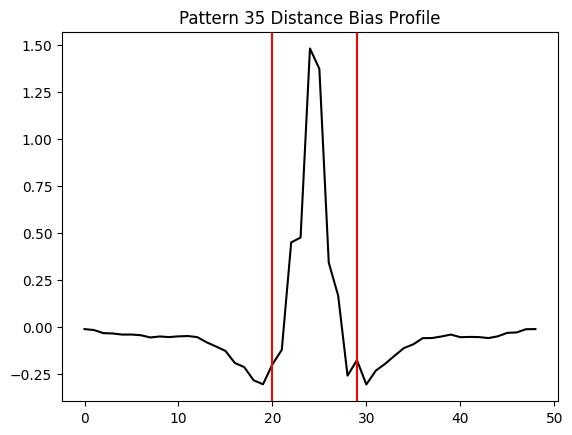

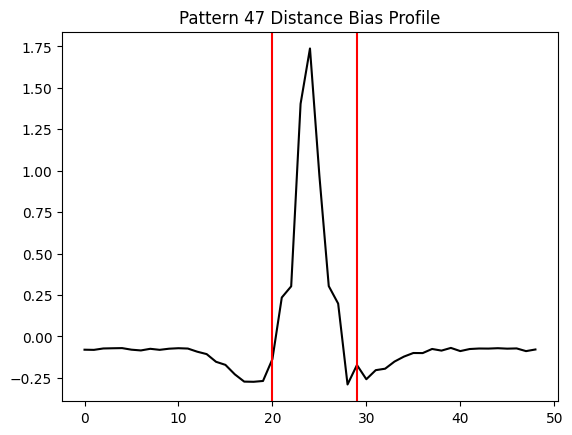

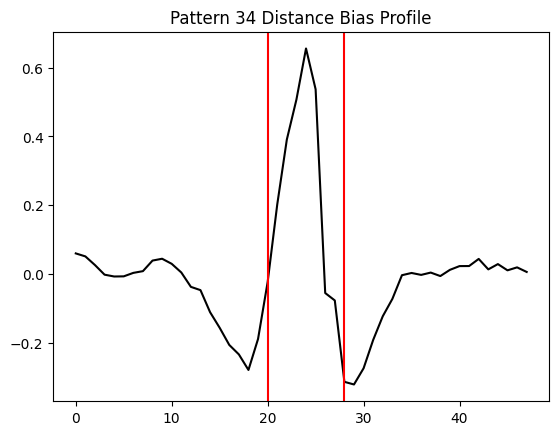

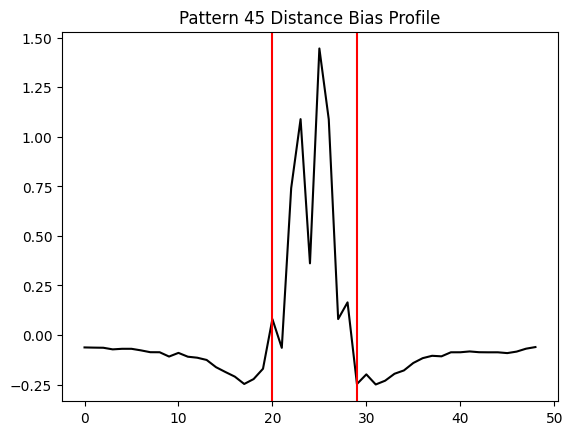

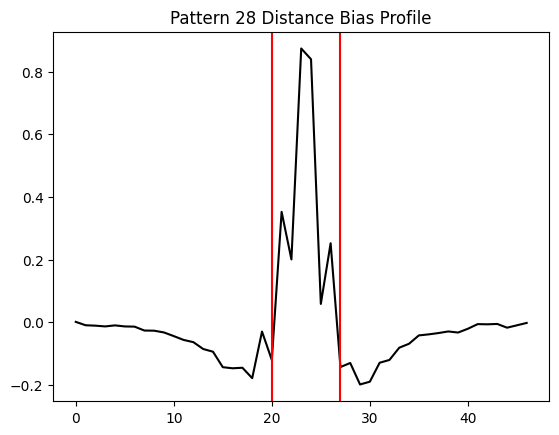

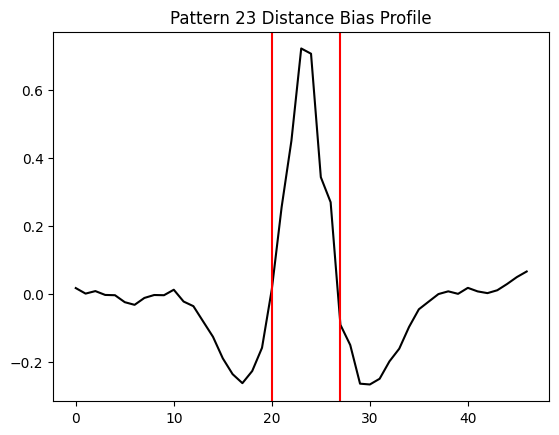

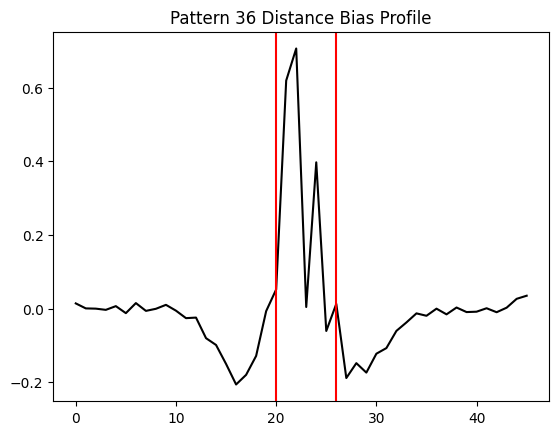

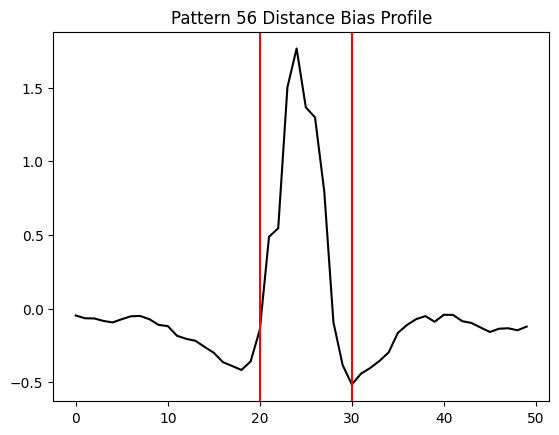

In [7]:
from tfmindi.tl import distance_bias
import matplotlib.pyplot as plt

bias_detectors = {
    k: distance_bias.detect_fixed_distance_bias(adata=adata, pattern=pattern, window=20)
    for k, pattern in patterns.items()
}

for pattern in tqdm(bias_detectors):
    bias_detectors[pattern].detect_distance_bias()
    profile, pattern_location, peaks = bias_detectors[pattern].profile_plot_data
    fig, ax = plt.subplots()
    title = f"Pattern {pattern} Distance Bias Profile"
    ax.plot(np.arange(profile.shape[0]), profile, color="black")
    for start_end in pattern_location:
        # plot location of the pattern
        ax.axvline(start_end, color="red")
    for peak_left, peak_right in peaks:
        # plot location of identified peaks
        ax.axvline(peak_left, color="orange")
        ax.axvline(peak_right, color="orange")
    ax.set_title(title)

(np.int64(11), 0)


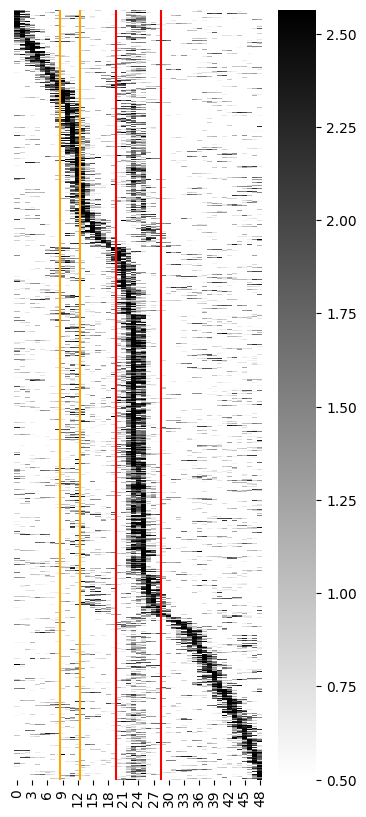

In [8]:
import seaborn as sns
from tfmindi.tl import distance_bias

pattern_id = "50"
contribution, pattern_location, peaks = bias_detectors[pattern_id].heatmap_plot_data
print(bias_detectors[pattern_id].up_downstream_window)
# 9, 0 <---the instances of this pattern will be extended by 9 bp upstream in the next code block.

fig, ax = plt.subplots(figsize=(4, 10))
sns.heatmap(contribution, cmap="gray_r", robust=True, ax=ax, yticklabels=False, vmin=0.5)
for start_end in pattern_location:
    # plot location of the pattern
    ax.axvline(start_end, color="red")
for peak_left, peak_right in peaks:
    # plot location of identified peaks
    ax.axvline(peak_left, color="orange")
    ax.axvline(peak_right, color="orange")

In [9]:
new_seqlet_df, new_seqlet_matrices = distance_bias.create_seqlet_matrices_with_distance_bias(
    adata=adata, fixed_distance_bias_detectors=bias_detectors.values(), threshold=0.5, extra_flanks_to_add=10
)

Processing seqlets: 100%|██████████| 670102/670102 [00:17<00:00, 37624.41it/s]


In [10]:
new_similarity_matrix = tm.pp.calculate_motif_similarity(new_seqlet_matrices, motif_collection, chunk_size=10000)

Processing chunks:  34%|███▍      | 23/68 [13:16<24:15, 32.35s/it]

: 